In [1]:
import os
import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
#from google.colab import drive

#drive.mount('/content/gdrive')

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

2023-04-28 03:05:31.199102: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-04-28 03:05:32.148837: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /opt/amazon/efa/lib:/opt/amazon/openmpi/lib:/usr/local/cuda/efa/lib:/usr/local/cuda/lib:/usr/local/cuda:/usr/local/cuda/lib64:/usr/local/cuda/extras/CUPTI/lib64:/usr/local/cuda/targets/x86_64-linux/lib:/usr/local/lib:/usr/lib:
2023-04-28 03:05:32.148975: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: lib

In [2]:
# read in the merged station datasets
dfs = {}
for index in range(0, 6) :
  df = pd.read_csv('merged_' + str(index + 1) + '.dat', sep=",", parse_dates=["Date"], index_col="Date")
  dfs['Station' + str(index + 1)] = df
print(len(dfs))
dfs['Station1'].head()

6


,Ppt_x,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Flag,Ppt_y,Tair,RH,Windspeed,Winddirection,Srad
Date,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,0.0,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,3,0.0,-1.090,81.5,1.052,52.27,0.63
2015-01-01 01:00:00,0.0,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,3,0.0,-1.038,81.7,0.959,46.71,0.62
2015-01-01 02:00:00,0.0,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,3,0.0,-0.981,82.0,1.062,52.04,0.60
2015-01-01 03:00:00,0.0,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,3,0.0,-0.814,81.9,0.887,58.91,0.64
2015-01-01 04:00:00,0.0,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,3,0.0,-0.805,90.0,0.828,16.55,0.20


In [3]:
# statistics of the station 1 dataset for example
dfs['Station1'].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Ppt_x,57859.0,0.068852,0.857941,0.000,0.000,0.000,0.000,42.160
SWC_5,57795.0,0.142987,0.052115,0.043,0.098,0.137,0.186,0.309
SWC_10,57846.0,0.156679,0.040268,0.084,0.123,0.155,0.190,0.298
SWC_20,57649.0,0.138416,0.033171,0.086,0.106,0.139,0.166,0.235
SWC_50,57834.0,0.138174,0.035402,0.087,0.104,0.130,0.170,0.249
T_5,57859.0,22.927269,9.519754,0.760,15.500,22.940,30.050,49.960
T_10,57859.0,22.934645,8.910221,1.780,15.740,23.090,30.150,44.440
T_20,57859.0,22.868688,8.425604,2.760,15.880,23.040,30.010,41.200
T_50,57859.0,22.693762,7.055595,5.960,16.380,22.540,29.210,35.400
Flag,58441.0,185.475967,1434.941793,0.000,0.000,0.000,0.000,13107.000


In [4]:
# Check if dfs contains NaN values
for station, df in dfs.items() :
  print(station)
  print(df.isnull().sum())
  print()

Station1
Ppt_x            582
SWC_5            646
SWC_10           595
SWC_20           792
SWC_50           607
T_5              582
T_10             582
T_20             582
T_50             582
Flag               0
Ppt_y            583
Tair             588
RH               583
Windspeed        583
Winddirection    583
Srad             583
dtype: int64

Station2
Ppt_x            0
SWC_5            2
SWC_10           1
SWC_20           1
SWC_50           0
T_5              0
T_10             0
T_20             0
T_50             0
Flag             0
Ppt_y            0
Tair             0
RH               0
Windspeed        0
Winddirection    0
Srad             0
dtype: int64

Station3
Ppt_x             0
SWC_5             0
SWC_10            0
SWC_20            0
SWC_50            0
T_5               0
T_10              0
T_20              0
T_50              0
Flag              0
Ppt_y             0
Tair              0
RH                0
Windspeed         0
Winddirection     0
Srad 

Station 4 has completely null columns for SWC_50 and T_50. I can't train on null values. To keep the integrity of the training, I chose not to impute those two entire columns with a constant value (which might mess up learning). I am choosing to remove Station 4 from analysis until a potential fix for this issue and to allow for optimal training.

In [5]:
del dfs['Station4']
print(dfs.keys())

dict_keys(['Station1', 'Station2', 'Station3', 'Station5', 'Station6'])


In [6]:
# drop NaN values to prevent issues when training (if NaN values are left in the df, loss cannot compute and training cannot occur)
for station, df in dfs.items() :
  print(station)
  df_new = df.dropna()
  print(df_new.isnull().sum())
  dfs[station] = df_new
  print()

Station1
Ppt_x            0
SWC_5            0
SWC_10           0
SWC_20           0
SWC_50           0
T_5              0
T_10             0
T_20             0
T_50             0
Flag             0
Ppt_y            0
Tair             0
RH               0
Windspeed        0
Winddirection    0
Srad             0
dtype: int64

Station2
Ppt_x            0
SWC_5            0
SWC_10           0
SWC_20           0
SWC_50           0
T_5              0
T_10             0
T_20             0
T_50             0
Flag             0
Ppt_y            0
Tair             0
RH               0
Windspeed        0
Winddirection    0
Srad             0
dtype: int64

Station3
Ppt_x            0
SWC_5            0
SWC_10           0
SWC_20           0
SWC_50           0
T_5              0
T_10             0
T_20             0
T_50             0
Flag             0
Ppt_y            0
Tair             0
RH               0
Windspeed        0
Winddirection    0
Srad             0
dtype: int64

Station5
Ppt_x     

In [7]:
for station, df in dfs.items() :
  # drop the Flag feature (it is not relevant to our soil data and can cause our ML model to pick on unneccesary patterns)
  df = df.drop('Flag', axis = 1)
  # rename Ppt columns to identify whether the precipitation was recorded as a part of soil data or meteorological data
  df_new = df.rename(columns = {'Ppt_x' : 'Ppt_soil', 'Ppt_y': 'Ppt_met'})
  print(station)
  print(df_new.describe().transpose())
  dfs[station] = df_new
  print()

Station1
                 count        mean         std      min       25%      50%  \
Ppt_soil       57586.0    0.068296    0.851118    0.000    0.0000    0.000   
SWC_5          57586.0    0.142906    0.052128    0.043    0.0980    0.137   
SWC_10         57586.0    0.156554    0.040289    0.084    0.1220    0.155   
SWC_20         57586.0    0.138393    0.033162    0.086    0.1060    0.139   
SWC_50         57586.0    0.138267    0.035442    0.087    0.1040    0.130   
T_5            57586.0   22.889934    9.522205    0.760   15.4600   22.890   
T_10           57586.0   22.899269    8.913519    1.780   15.7025   23.020   
T_20           57586.0   22.835817    8.430082    2.760   15.8400   22.980   
T_50           57586.0   22.667777    7.061287    5.960   16.3500   22.470   
Ppt_met        57586.0    0.068336    0.851120    0.000    0.0000    0.000   
Tair           57586.0   14.858769   22.046219 -173.200   12.0200   19.480   
RH             57586.0   64.900222   28.543891  -96.300

Text(0, 0.5, 'Wind Velocity [m/s]')

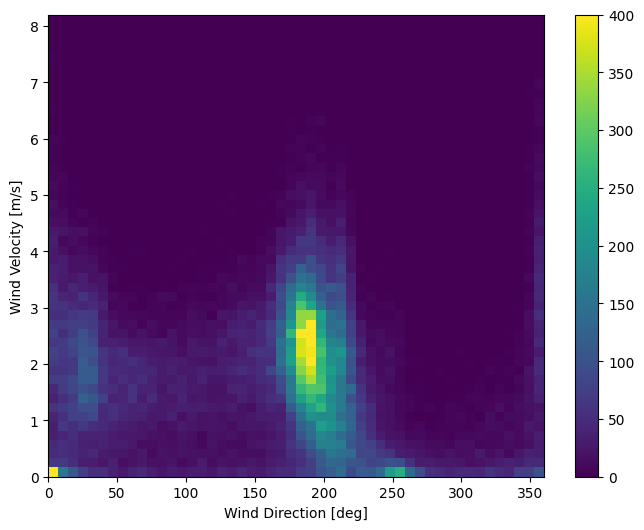

In [8]:
# distribution of wind data (station 1 for example)
plt.hist2d(dfs['Station1']['Winddirection'], dfs['Station1']['Windspeed'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel('Wind Direction [deg]')
plt.ylabel('Wind Velocity [m/s]')

In [9]:
for station, df in dfs.items() :
  # convert wind velocity and wind direction to a wind vector
  wv = df.pop('Windspeed')

  # Convert to radians.
  wd_rad = df.pop('Winddirection')*np.pi / 180

  # Calculate the wind x and y components.
  df['Wx'] = wv*np.cos(wd_rad)
  df['Wy'] = wv*np.sin(wd_rad)
  dfs[station] = df

(-7.808186098707588, 8.1975522162057, -4.273160359540029, 4.754479689602174)

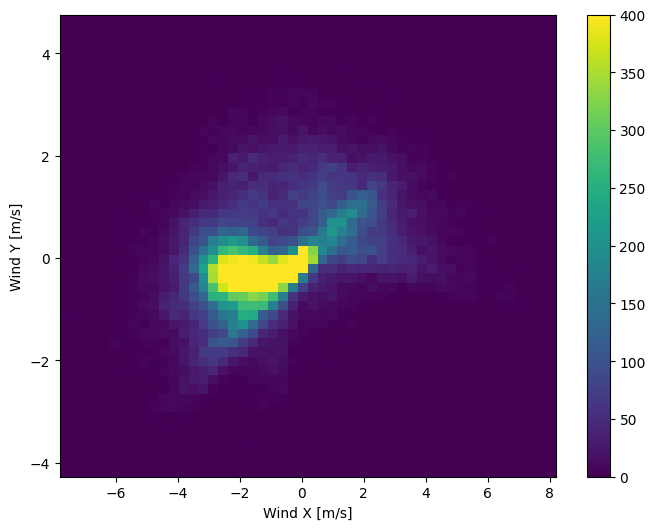

In [10]:
# The distribution of wind vectors is much simpler for the model to correctly interpret (station 1 for example)
plt.hist2d(dfs['Station1']['Wx'], dfs['Station1']['Wy'], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel('Wind X [m/s]')
plt.ylabel('Wind Y [m/s]')
ax = plt.gca()
ax.axis('tight')

In [11]:
# Remove periodicity in time data (remove daily and yearly periodicity)
day = 24*60*60
year = (365.2425)*day

for station, df in dfs.items() :
  timestamp_s = (df.index).map(pd.Timestamp.timestamp)

  df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
  df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
  df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
  df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

  dfs[station] = df

Text(0.5, 1.0, 'Time of day signal')

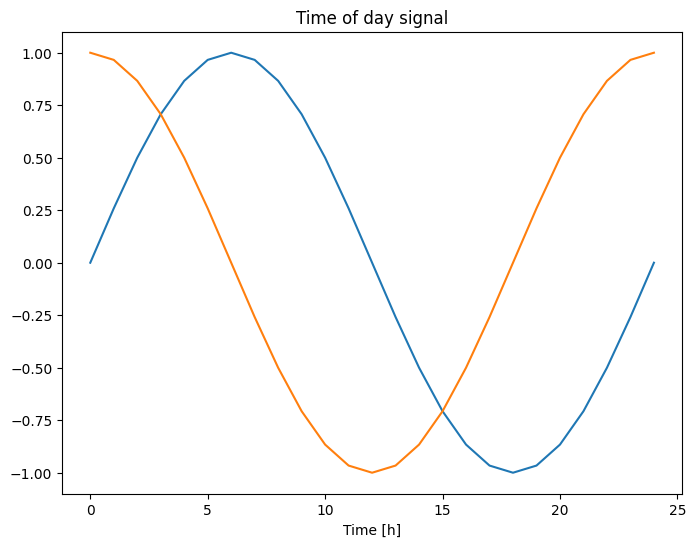

In [12]:
# plot day sin and cos (station 1 for example)
plt.plot(np.array(dfs['Station1']['Day sin'])[:25])
plt.plot(np.array(dfs['Station1']['Day cos'])[:25])
plt.xlabel('Time [h]')
plt.title('Time of day signal')

In [13]:
# Split the dataset into train, validation, and test sets
# 2015-2020 (training data), 2021 (validation data [every station except station 3]), Station 3 2021 (testing data)
column_indices = {name: i for i, name in enumerate(dfs['Station1'].columns)}

train_list = []
val_list = []

# get all training dfs from each station
for station, df in dfs.items() :
  df = df.loc['2015':'2020']
  train_list.append(df)

# get all validation dfs from each station
for station, df in dfs.items() :
  if station == 'Station3' :
    continue
  df = df.loc['2021']
  val_list.append(df)

# create a merged, singular train_df
train_df = None
not_set = True
for df in train_list :
    if not_set :
      train_df = df
      not_set = False
      continue
    train_df = train_df.append(df, ignore_index=True)

# create a merged, singular val_df
val_df = None
not_set = True
for df in val_list :
    if not_set :
      val_df = df
      not_set = False
      continue
    val_df = val_df.append(df, ignore_index=True)

# get the testing df
test_df = dfs['Station3'].loc['2021']

print('years in train df: ' + str((len(train_df) / 24 / 365)))
print('years in val df: ' + str((len(val_df) / 24 / 365)))
print('years in test df: ' + str((len(test_df) / 24 / 365)))

num_features = dfs['Station1'].shape[1]

years in train df: 28.69497716894977
years in val df: 2.426598173515982
years in test df: 0.6658675799086757


/tmp/ipykernel_8985/3286330689.py:28: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  train_df = train_df.append(df, ignore_index=True)
/tmp/ipykernel_8985/3286330689.py:38: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  val_df = val_df.append(df, ignore_index=True)


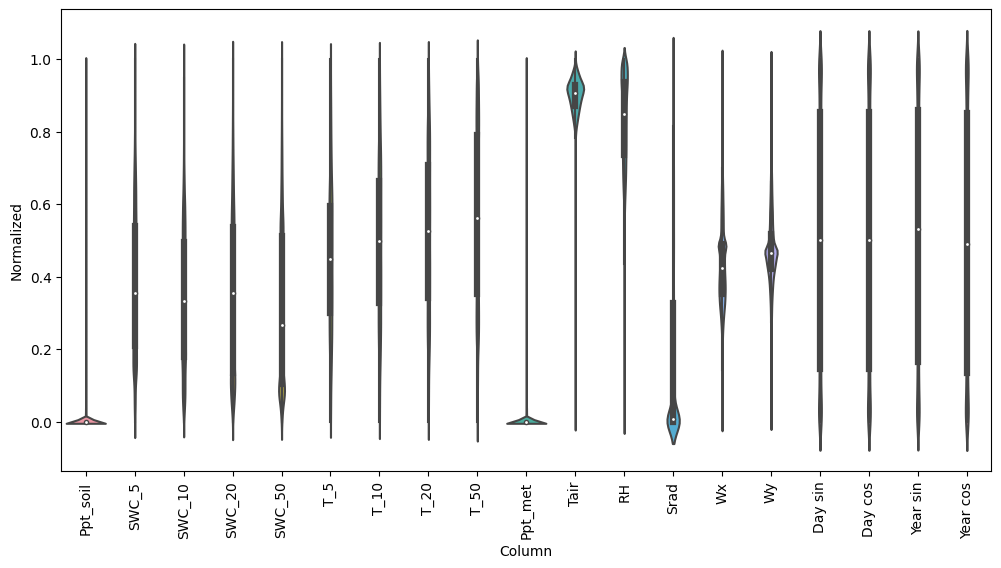

In [14]:
# normalize the data (using min-max normalization)
train_df = (train_df - train_df.min()) / (train_df.max() - train_df.min())
val_df = (val_df - val_df.min()) / (val_df.max() - val_df.min())
test_df = (test_df - test_df.min()) / (test_df.max() - test_df.min())

# look at distribution of values (Station 1 for example)
df_std = (dfs['Station1'] - dfs['Station1'].min()) / (dfs['Station1'].max() - dfs['Station1'].min())
df_std = df_std.melt(var_name='Column', value_name='Normalized')
plt.figure(figsize=(12, 6))
ax = sns.violinplot(x='Column', y='Normalized', data=df_std)
_ = ax.set_xticklabels(dfs['Station1'].keys(), rotation=90)

In [15]:
# create window generator class
class WindowGenerator():
  def __init__(self, input_width, label_width, shift,
               train_df=train_df, val_df=val_df, test_df=test_df,
               label_columns=None):
    # Store the raw data.
    self.train_df = train_df
    self.val_df = val_df
    self.test_df = test_df

    # Work out the label column indices.
    self.label_columns = label_columns
    if label_columns is not None:
      self.label_columns_indices = {name: i for i, name in
                                    enumerate(label_columns)}
    self.column_indices = {name: i for i, name in
                           enumerate(train_df.columns)}

    # Work out the window parameters.
    self.input_width = input_width
    self.label_width = label_width
    self.shift = shift

    self.total_window_size = input_width + shift

    self.input_slice = slice(0, input_width)
    self.input_indices = np.arange(self.total_window_size)[self.input_slice]

    self.label_start = self.total_window_size - self.label_width
    self.labels_slice = slice(self.label_start, None)
    self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

  def __repr__(self):
    return '\n'.join([
        f'Total window size: {self.total_window_size}',
        f'Input indices: {self.input_indices}',
        f'Label indices: {self.label_indices}',
        f'Label column name(s): {self.label_columns}'])

In [16]:
# create windowing function
def split_window(self, features):
  inputs = features[:, self.input_slice, :]
  labels = features[:, self.labels_slice, :]
  if self.label_columns is not None:
    labels = tf.stack(
        [labels[:, :, self.column_indices[name]] for name in self.label_columns],
        axis=-1)

  # Slicing doesn't preserve static shape information, so set the shapes
  # manually. This way the `tf.data.Datasets` are easier to inspect.
  inputs.set_shape([None, self.input_width, None])
  labels.set_shape([None, self.label_width, None])

  return inputs, labels

WindowGenerator.split_window = split_window

In [17]:
# simple visualization of the window
def plot(self, model=None, plot_col='SWC_5', max_subplots=3):
  inputs, labels = self.example
  plt.figure(figsize=(12, 8))
  plot_col_index = self.column_indices[plot_col]
  max_n = min(max_subplots, len(inputs))
  for n in range(max_n):
    plt.subplot(max_n, 1, n+1)
    plt.ylabel(f'{plot_col} [normed]')
    plt.plot(self.input_indices, inputs[n, :, plot_col_index],
             label='Inputs', marker='.', zorder=-10)

    if self.label_columns:
      label_col_index = self.label_columns_indices.get(plot_col, None)
    else:
      label_col_index = plot_col_index

    if label_col_index is None:
      continue

    plt.scatter(self.label_indices, labels[n, :, label_col_index],
                edgecolors='k', label='Labels', c='#2ca02c', s=64)
    if model is not None:
      predictions = model(inputs)
      plt.scatter(self.label_indices, predictions[n, :, label_col_index],
                  marker='X', edgecolors='k', label='Predictions',
                  c='#ff7f0e', s=64)

    if n == 0:
      plt.legend()

  plt.xlabel('Time [h]')

WindowGenerator.plot = plot

In [18]:
# visualize how the model predicted on all of the test data
def plot_all(self, model=None, plot_col='SWC_5'):

  plt.figure(figsize=(12, 8))
  plot_col_index = self.column_indices[plot_col]
  label_idx = self.label_indices

  # make a new test dataset with inputs and outputs that don't overlap time units (so that we get one smooth graph)
  test_tensor = self.make_dataset_no_overlap(self.test_df)

  # create list of the number of hours in the test df and plot test labels
  all_idx = [num for num in range(len(self.test_df))]
  plt.plot(all_idx, self.test_df[plot_col], marker='.', zorder=-10)
  plt.ylabel(f'{plot_col} [normed]')

  batch_num = 1
  # iterate through all batches of data
  for batch in test_tensor:
    print('Batch number: ', batch_num)
    
    # extract the inputs and the labels from the example batch
    inputs, labels = batch  

    if self.label_columns:
      label_col_index = self.label_columns_indices.get(plot_col, None)
    else:
      label_col_index = plot_col_index

    if label_col_index is None:
      continue

    # if we passed in a model, see what predictions we get
    if model is not None:
      predictions = model(inputs)

      #print('predictions shape')
      # Get the shape of the tensor
      #print(predictions.shape)

      # iterate through example in the batch
      for n in range(predictions.shape[0]) :

        # plot the predictions for this example
        plt.scatter(label_idx, predictions[n, : , label_col_index],
                    marker='X', edgecolors='k',
                    c='#ff7f0e', s=15)
        
        label_idx = [num + self.total_window_size for num in label_idx]
      
    # increment batch number
    batch_num += 1

  plt.legend(('True Values', 'Predictions'))
  plt.xlabel('Time [h]')

WindowGenerator.plot_all = plot_all

In [19]:
# make dataset from a tf.data.Dataset of (input_window, label_window) pairs 
def make_dataset(self, data):
  data = np.array(data, dtype=np.float32)
  ds = tf.keras.utils.timeseries_dataset_from_array(
      data=data,
      targets=None,
      sequence_length=self.total_window_size,
      sequence_stride=1,
      shuffle=True,
      batch_size=32,)

  ds = ds.map(self.split_window)

  return ds

WindowGenerator.make_dataset = make_dataset

In [20]:
# make dataset from a tf.data.Dataset of (input_window, label_window) pairs without overlapping time units
def make_dataset_no_overlap(self, data):
  data = np.array(data, dtype=np.float32)
  ds = tf.keras.utils.timeseries_dataset_from_array(
      data=data,
      targets=None,
      sequence_length=self.total_window_size,
      sequence_stride=self.total_window_size,
      # create windows in chronological order (for graphing purposes)
      shuffle=False,
      batch_size=32,)

  ds = ds.map(self.split_window)

  return ds

WindowGenerator.make_dataset_no_overlap = make_dataset_no_overlap

In [21]:
# Add properties for accessing train, val, and test data as tf.data.Datasets using the make_dataset method you defined earlier
# Also, add a standard example batch for easy access and plotting
@property
def train(self):
  return self.make_dataset(self.train_df)

@property
def val(self):
  return self.make_dataset(self.val_df)

@property
def test(self):
  return self.make_dataset(self.test_df)

@property
def example(self):
  """Get and cache an example batch of `inputs, labels` for plotting."""
  result = getattr(self, '_example', None)
  if result is None:
    # No example batch was found, so get one from the `.test` dataset
    result = next(iter(self.test))
    # And cache it for next time
    self._example = result
  return result

WindowGenerator.train = train
WindowGenerator.val = val
WindowGenerator.test = test
WindowGenerator.example = example

In [109]:
# generate a wide window of 7 days of consecutive inputs and labels
days = 7

wide_window = WindowGenerator(
    input_width=24 * days, label_width=24 * days, shift=1,
    label_columns=['SWC_5'])

wide_window

Total window size: 169
Input indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167]
Label indices: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65 

In [110]:
# training procedure
MAX_EPOCHS = 100

val_performance = {}
performance = {}

def compile_and_fit(model, window, patience=2):
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min')

  model.compile(loss=tf.keras.losses.MeanSquaredError(),
                optimizer=tf.keras.optimizers.Adam(learning_rate = 0.001),
                metrics=[tf.keras.metrics.MeanAbsoluteError()])

  history = model.fit(window.train, epochs=MAX_EPOCHS,
                      validation_data=window.val,
                      callbacks=[early_stopping])
  return history

I am going to be using an RNN LSTM Model where return_sequences = True. This is because the current use case fits the Tensorflow tutorial page:

*If True, the layer returns an output for each input. This is useful for:*
- *Stacking RNN layers.*
- *Training a model on multiple time steps simultaneously.*

I have configured my window to fit this architecture, as I have an output for each consecutive input (as indicated in the tutorial above).

In [111]:
# Create a RNN LSTM model where return_sequences is True (predicts an output for each input along the way)
lstm_model = tf.keras.models.Sequential([
    # Shape [batch, time, features] => [batch, time, lstm_units]
    tf.keras.layers.LSTM(32, activation='tanh', return_sequences=True),
    tf.keras.layers.LSTM(16, activation='tanh', return_sequences=True),
    # Shape => [batch, time, features]
    tf.keras.layers.Dense(units=1)
])

In [112]:
print('Input shape:', wide_window.example[0].shape)
print('Output shape:', lstm_model(wide_window.example[0]).shape)

Input shape: (32, 168, 19)
Output shape: (32, 168, 1)


In [113]:
# train and evaluate the RNN LSTM model
history = compile_and_fit(lstm_model, wide_window)

#IPython.display.clear_output()
val_performance['LSTM'] = lstm_model.evaluate(wide_window.val)
performance['LSTM'] = lstm_model.evaluate(wide_window.test, verbose=0)

Epoch 1/100
7850/7850 [==============================] - 97s 12ms/step - loss: 6.6831e-04 - mean_absolute_error: 0.0069 - val_loss: 9.3006e-05 - val_mean_absolute_error: 0.0063
Epoch 2/100
7850/7850 [==============================] - 92s 12ms/step - loss: 1.6444e-05 - mean_absolute_error: 0.0021 - val_loss: 5.6795e-05 - val_mean_absolute_error: 0.0033
Epoch 3/100
7850/7850 [==============================] - 93s 12ms/step - loss: 1.3151e-05 - mean_absolute_error: 0.0016 - val_loss: 4.7009e-05 - val_mean_absolute_error: 0.0017
Epoch 4/100
7850/7850 [==============================] - 93s 12ms/step - loss: 1.1024e-05 - mean_absolute_error: 0.0014 - val_loss: 4.8933e-05 - val_mean_absolute_error: 0.0020
Epoch 5/100
7850/7850 [==============================] - 93s 12ms/step - loss: 1.0202e-05 - mean_absolute_error: 0.0013 - val_loss: 4.6953e-05 - val_mean_absolute_error: 0.0015
Epoch 6/100
7850/7850 [==============================] - 93s 12ms/step - loss: 9.4112e-06 - mean_absolute_error: 0.

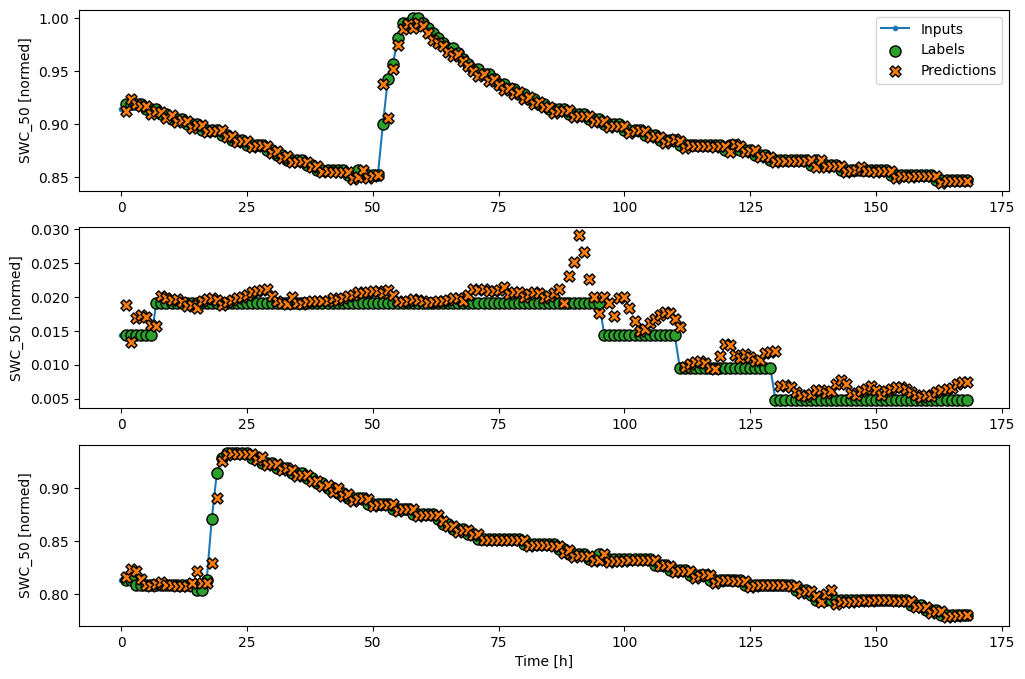

In [114]:
# plot the results of the model
wide_window.plot(lstm_model)

In [22]:
# plot lstm on the wide window for all time windows on the test data
wide_window.plot_all(lstm_model)

NameError: name 'wide_window' is not defined

Do a non-nested cross-validation loop to train LSTM RNN model over all the stations. The CV Loop architecture is as follows: 6 training years and 1 testing year.
- CV Loop is 7-fold and trains the 6 training years against the 1 testing dataset in each iteration
- after each iteration, an accuracy and loss is obtained
- datasets change each iteration in a sliding window fashion (as demonstrated in the image below)
  - each iteration of the training is done on a new instance of the LSTM RNN model to prevent testing on training data
- as a result, we get 5 LSTM RNN models with 5 accuracies and losses -> average the losses of all 5 models to provide the LSTM RNN model's performance on this dataset


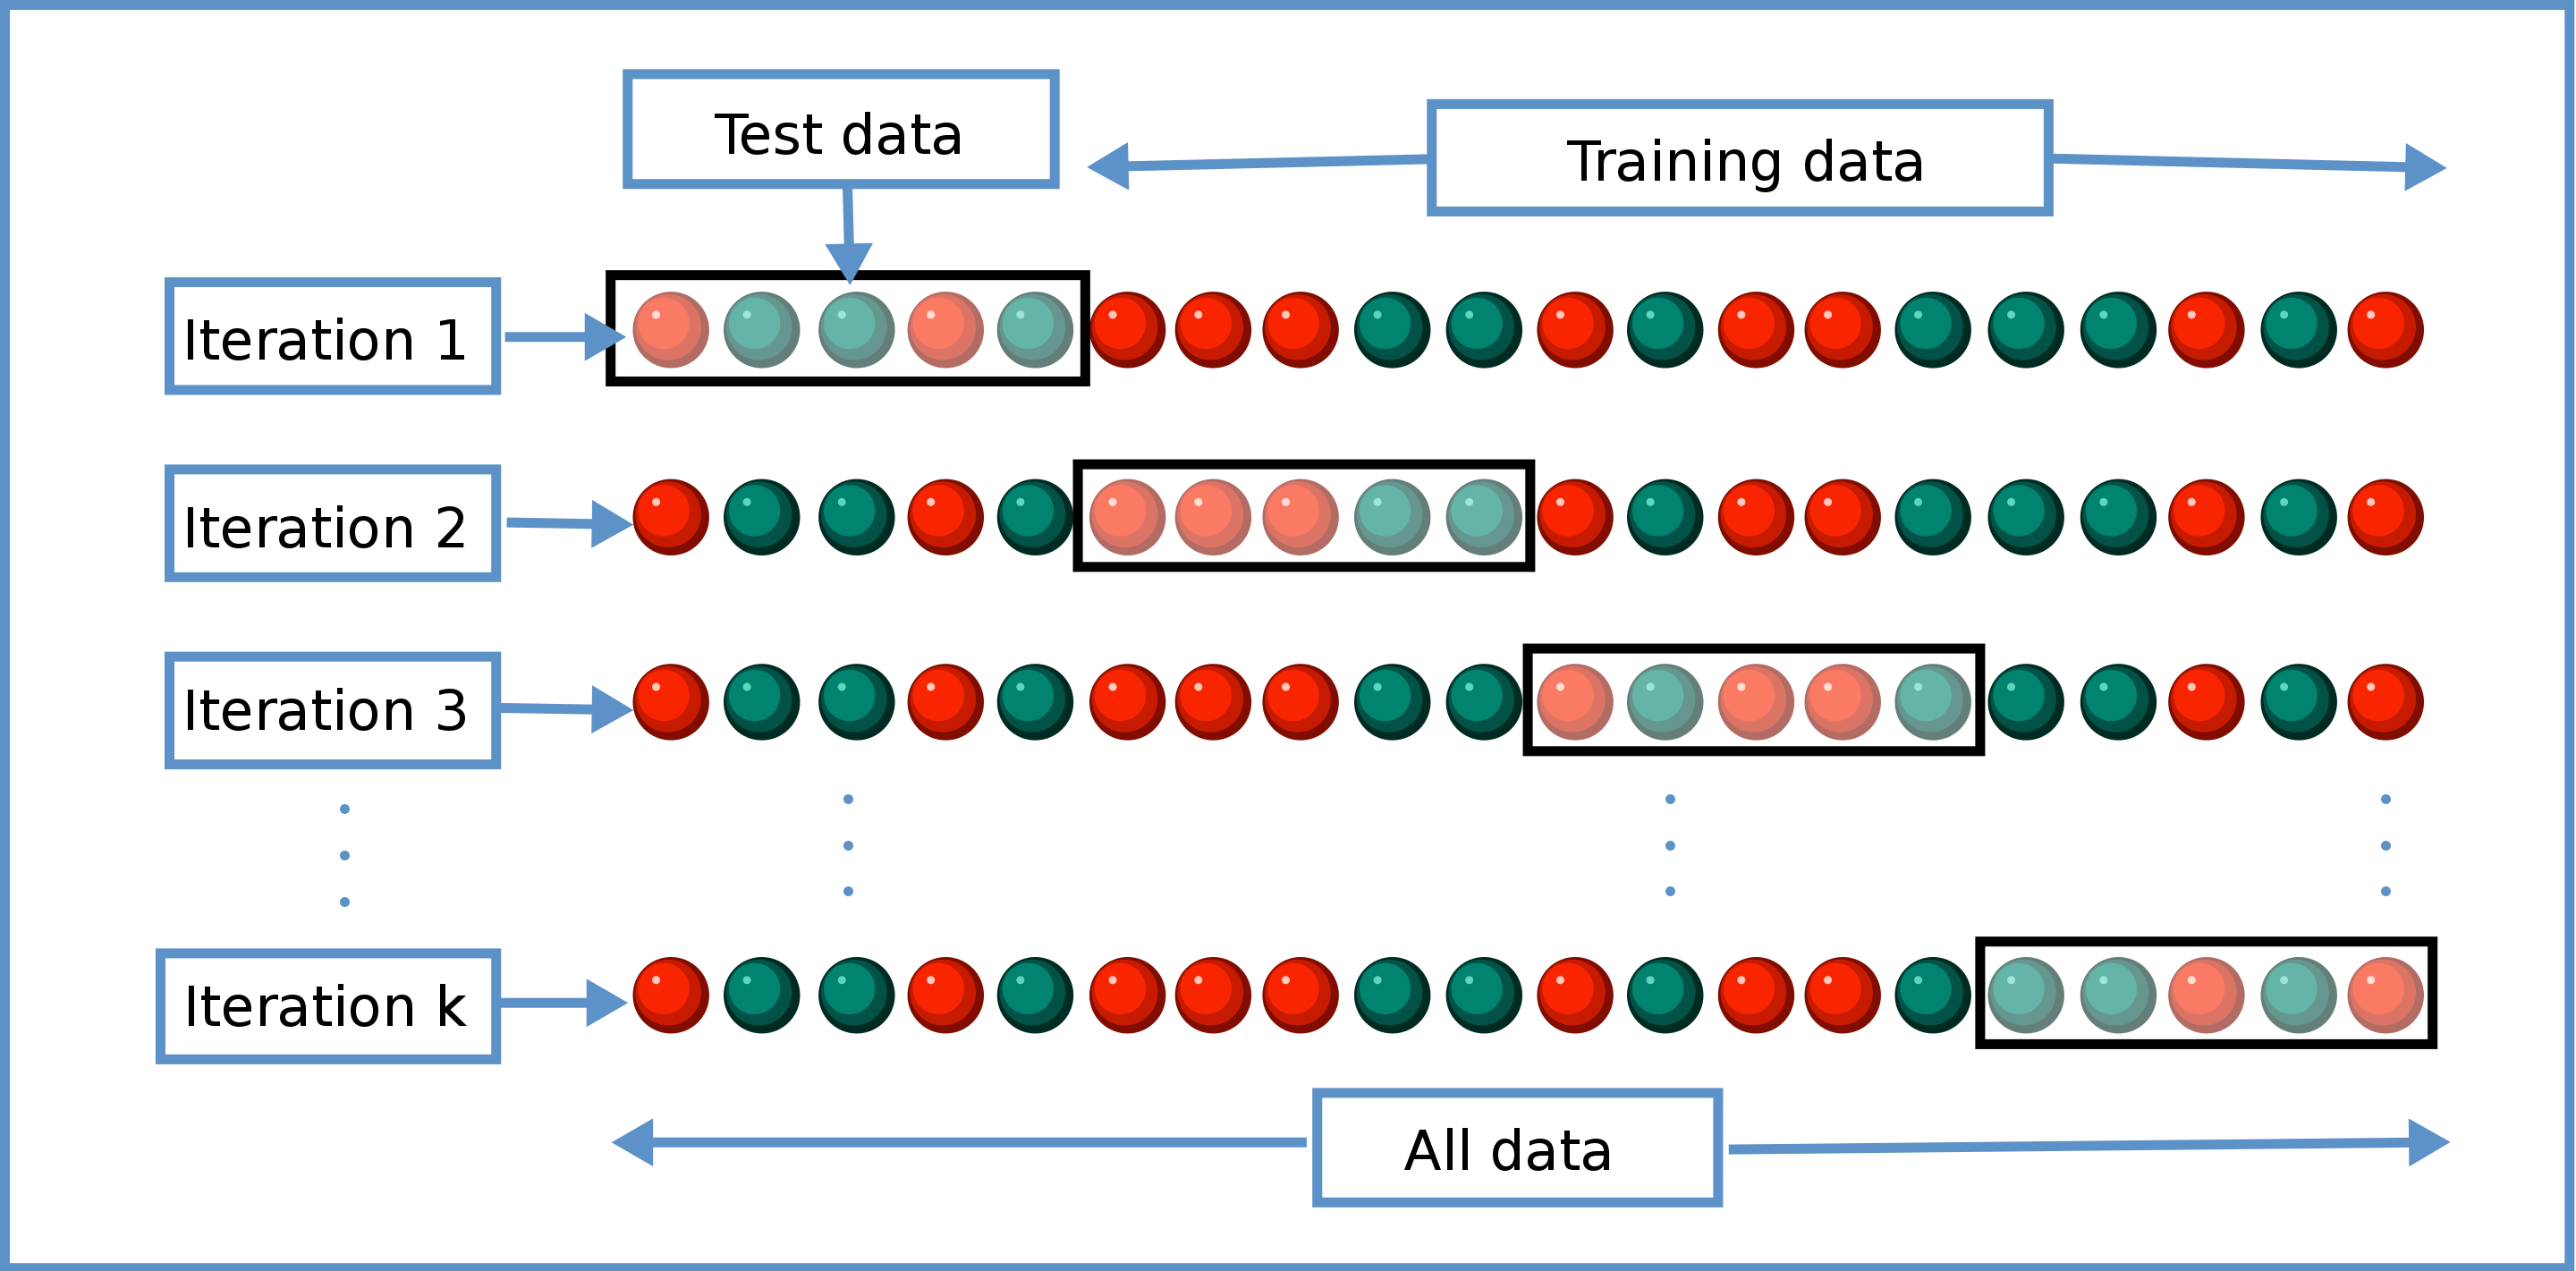

NOTE: I am not using validation set as this is a non-nested CV loop (as per the requirements of this task). Since
my goal is to not tune hyperparameters of the model in this task, not having validation data should be alright for this use case.

Additionally, as seen in the upcoming cell, I set MAX_EPOCHS to 7 epochs down from the previous 100 epochs. MAX_EPOCHS is 7 because keras early stopping, when monitoring loss, is not meaningful and will train unecessarily long. I can't monitor early stopping using val_loss (as I have done in the past) because this training has no validation data

In [23]:
# training procedure for non-nested K-Fold CV training
MAX_EPOCHS = 7

performance = {}

def compile_and_fit_noval(model, window, patience=2):
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='loss',
                                                    patience=patience,
                                                    mode='min')

  model.compile(loss=tf.keras.losses.MeanSquaredError(),
                optimizer=tf.keras.optimizers.Adam(learning_rate = 0.001),
                metrics=[tf.keras.metrics.MeanAbsoluteError()])

  history = model.fit(window.train, epochs=MAX_EPOCHS,
                      callbacks=[early_stopping])

  return history

In [24]:
# based on the fold number, obtain the correct train and test datasets
def get_split(fold_idx) :

  # lists to hold all cutoffs based on fold_idx
  train_c = [('2016', '2017', '2018', '2019', '2020', '2021'), 
             ('2015', '2017', '2018', '2019', '2020', '2021'),
             ('2015', '2016', '2018', '2019', '2020', '2021'),
             ('2015', '2016', '2017', '2019', '2020', '2021'),
             ('2015', '2016', '2017', '2018', '2020', '2021'),
             ('2015', '2016', '2017', '2018', '2019', '2021'),
             ('2015', '2016', '2017', '2018', '2019', '2020')]
  test_c = ['2015', '2016', '2017', '2018', '2019', '2020', '2021']
                                                    
  # Split the dataset into train and test sets
  column_indices = {name: i for i, name in enumerate(dfs['Station1'].columns)}

  train_list = []
  test_list = []

  # get all training dfs from each station
  for station, df in dfs.items() :
    train_yrs = train_c[fold_idx]
    # get the appropriate training years from each station
    for year in train_yrs :
        if station == 'Station5' and year == '2015':
            continue
        train_list.append(df.loc[year])
  
  # get the testing df
  for station, df in dfs.items() :
    if station == 'Station5' and fold_idx == 0:
            continue
    test_list.append(df.loc[test_c[fold_idx]])

  # create a merged, singular train_df
  train_df = None
  not_set = True
  for df in train_list :
      if not_set :
        train_df = df
        not_set = False
        continue
      train_df = train_df.append(df, ignore_index=True)

  # create a merged, singular test_df
  test_df = None
  not_set = True
  for df in test_list :
      if not_set :
        test_df = df
        not_set = False
        continue
      test_df = test_df.append(df, ignore_index=True)

  print('years in train df: ' + str((len(train_df) / 24 / 365)))
  print('years in test df: ' + str((len(test_df) / 24 / 365)))

  return train_df, test_df

In [25]:
# normalize the train_df and test_df
def normalize(train_df, test_df) :
  # normalize the data (using min-max normalization)
  train_df = (train_df - train_df.min()) / (train_df.max() - train_df.min())
  test_df = (test_df - test_df.min()) / (test_df.max() - test_df.min())

  return train_df, test_df

In [26]:
def generate_lstm() : 
  # Create a RNN LSTM model where return_sequences is True (predicts an output for each input along the way)
  lstm_model = tf.keras.models.Sequential([
    # Shape [batch, time, features] => [batch, time, lstm_units]
    tf.keras.layers.LSTM(32, activation='tanh', return_sequences=True),
    tf.keras.layers.LSTM(16, activation='tanh', return_sequences=True),
    # Shape => [batch, time, features]
    tf.keras.layers.Dense(units=1)
  ])

  return lstm_model

Fold 1


/tmp/ipykernel_8985/1763207781.py:43: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  train_df = train_df.append(df, ignore_index=True)
/tmp/ipykernel_8985/1763207781.py:53: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  test_df = test_df.append(df, ignore_index=True)


years in train df: 27.79988584474886
years in test df: 3.9875570776255707


2023-04-28 03:07:02.680751: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-04-28 03:07:02.686943: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-04-28 03:07:02.687159: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-04-28 03:07:02.687734: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorF

Epoch 1/7


2023-04-28 03:07:08.526138: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:428] Loaded cuDNN version 8400
Could not load symbol cublasGetSmCountTarget from libcublas.so.11. Error: /usr/local/cuda/lib64/libcublas.so.11: undefined symbol: cublasGetSmCountTarget
2023-04-28 03:07:08.759164: I tensorflow/compiler/xla/service/service.cc:173] XLA service 0x7fbc141a4290 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2023-04-28 03:07:08.759202: I tensorflow/compiler/xla/service/service.cc:181]   StreamExecutor device (0): Tesla V100-SXM2-16GB, Compute Capability 7.0
2023-04-28 03:07:08.764665: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2023-04-28 03:07:08.914183: I tensorflow/compiler/jit/xla_compilation_cache.cc:477] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


7605/7605 [==============================] - 91s 11ms/step - loss: 9.3657e-04 - mean_absolute_error: 0.0095
Epoch 2/7
7605/7605 [==============================] - 85s 11ms/step - loss: 8.8593e-05 - mean_absolute_error: 0.0034
Epoch 3/7
7605/7605 [==============================] - 85s 11ms/step - loss: 7.8581e-05 - mean_absolute_error: 0.0029
Epoch 4/7
7605/7605 [==============================] - 85s 11ms/step - loss: 7.3018e-05 - mean_absolute_error: 0.0027
Epoch 5/7
7605/7605 [==============================] - 85s 11ms/step - loss: 7.0338e-05 - mean_absolute_error: 0.0026
Epoch 6/7
7605/7605 [==============================] - 85s 11ms/step - loss: 6.6473e-05 - mean_absolute_error: 0.0025
Epoch 7/7
7605/7605 [==============================] - 86s 11ms/step - loss: 6.2178e-05 - mean_absolute_error: 0.0025
Batch number:  1
Batch number:  2
Batch number:  3
Batch number:  4
Batch number:  5
Batch number:  6
Batch number:  7

Fold 2
years in train df: 26.92066210045662
years in test df: 4.

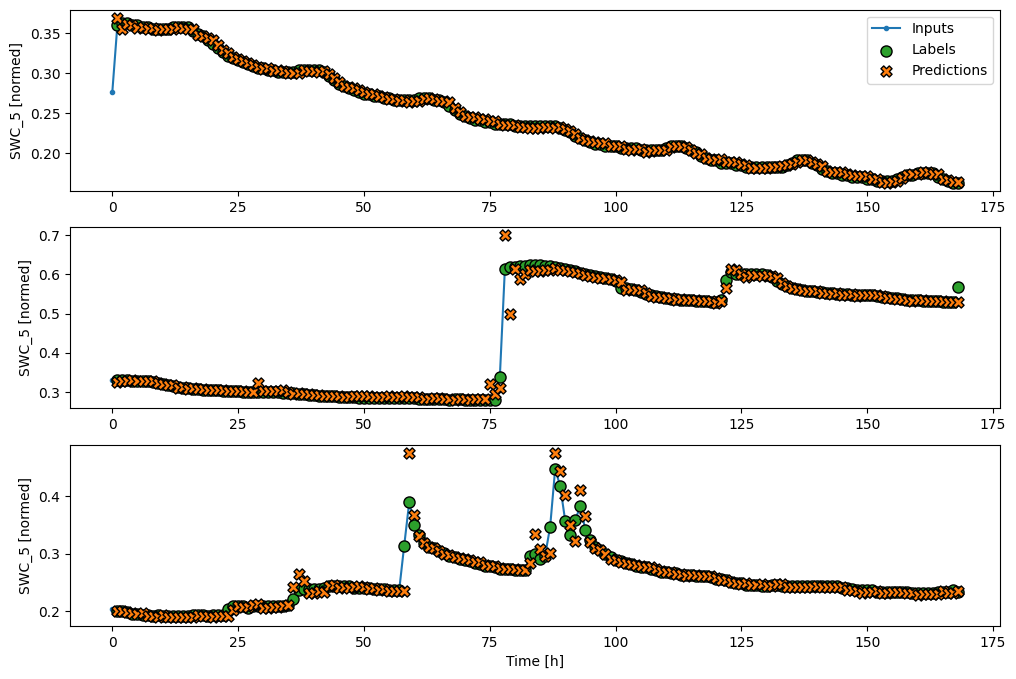

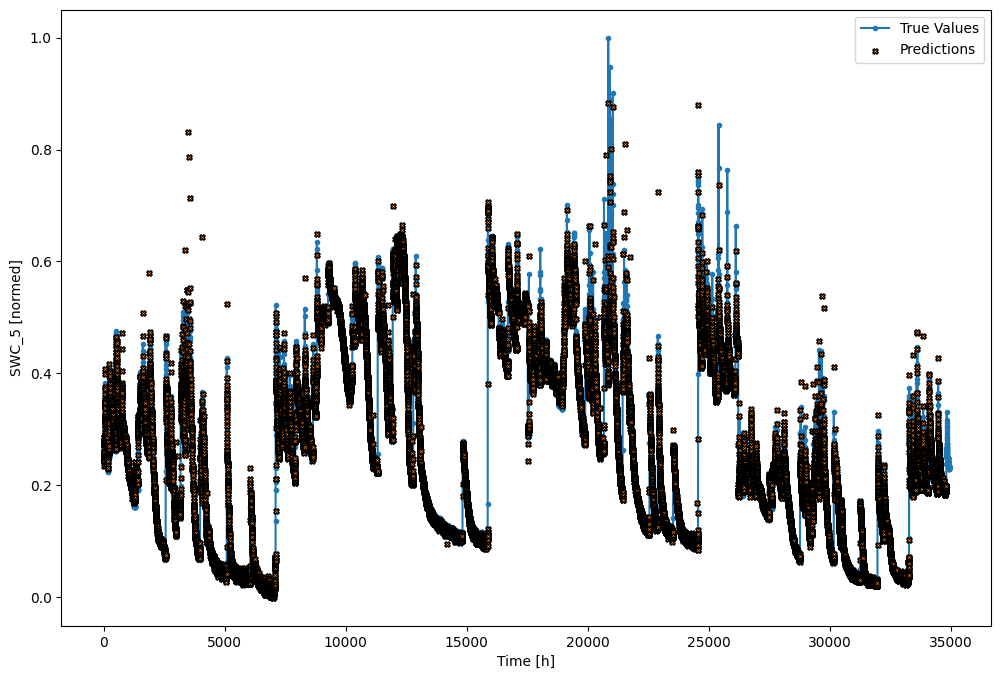

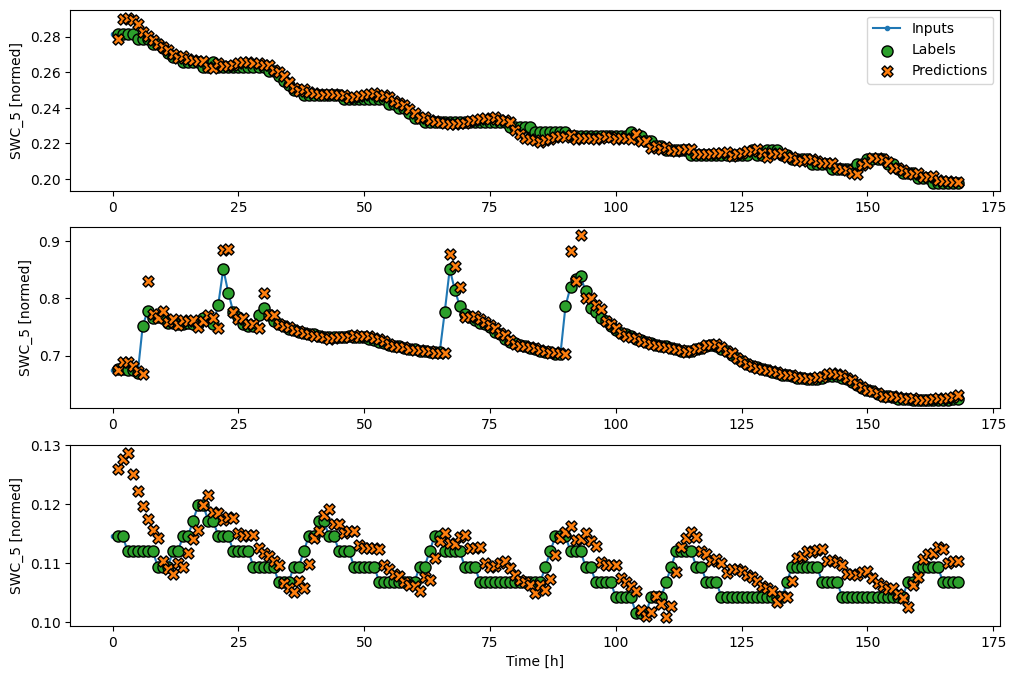

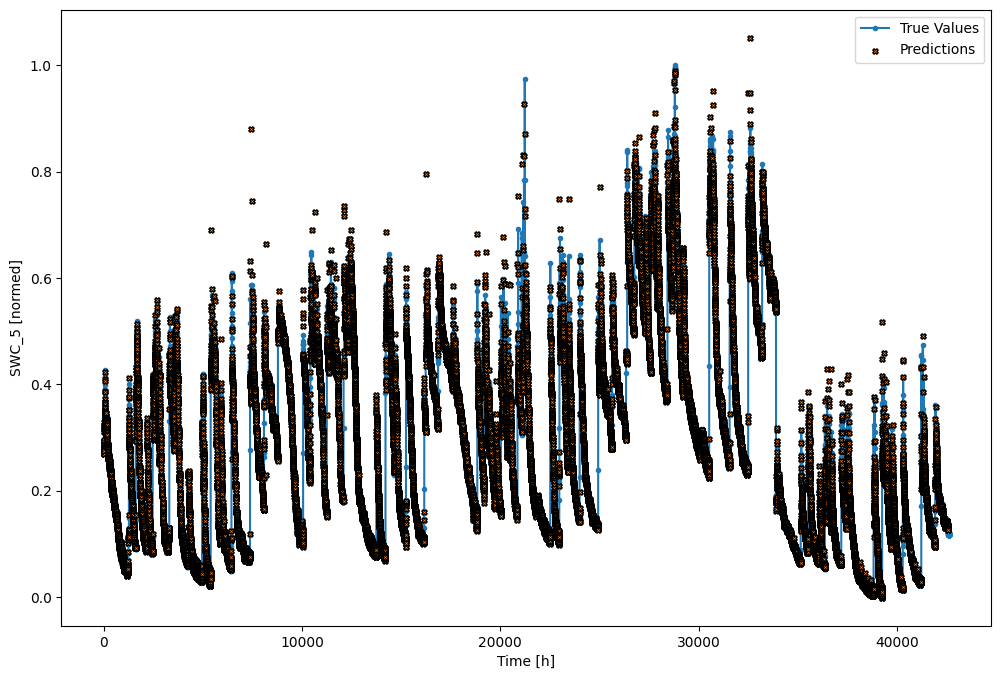

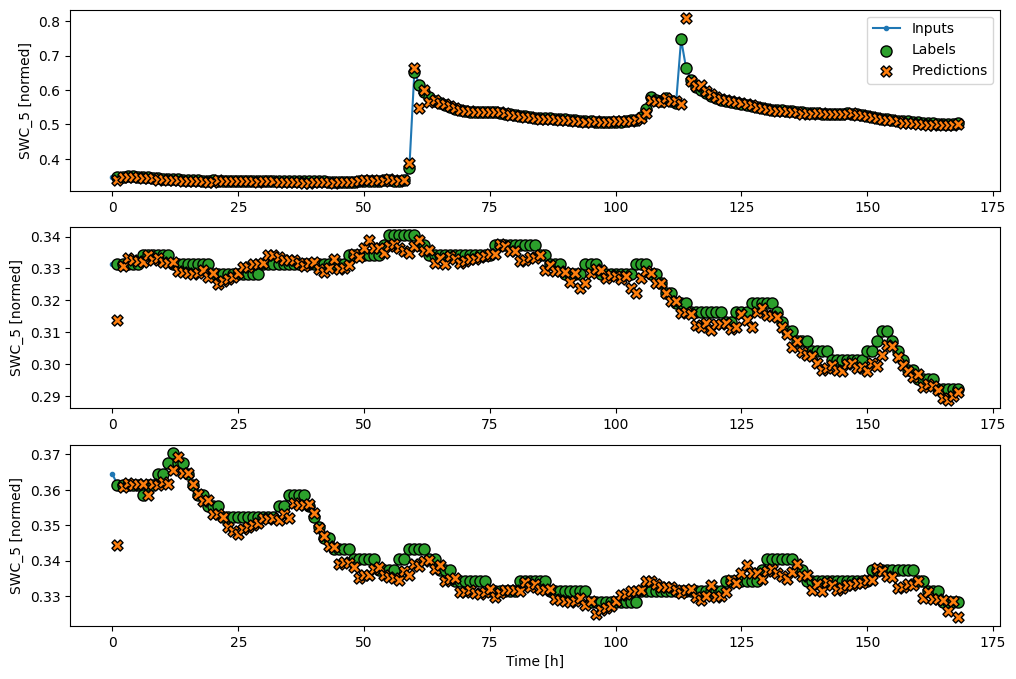

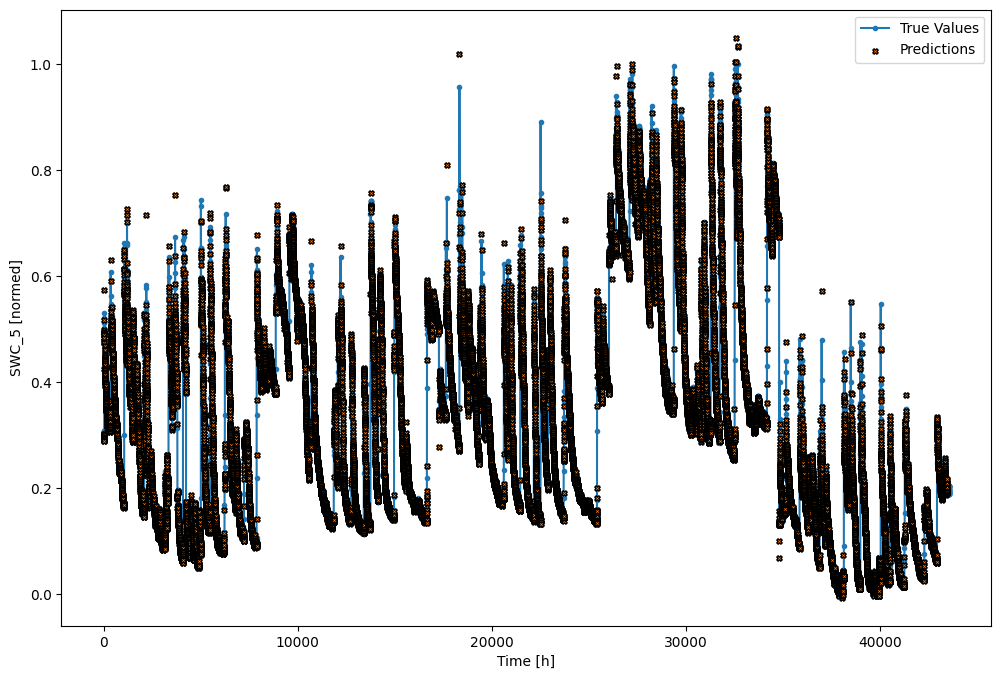

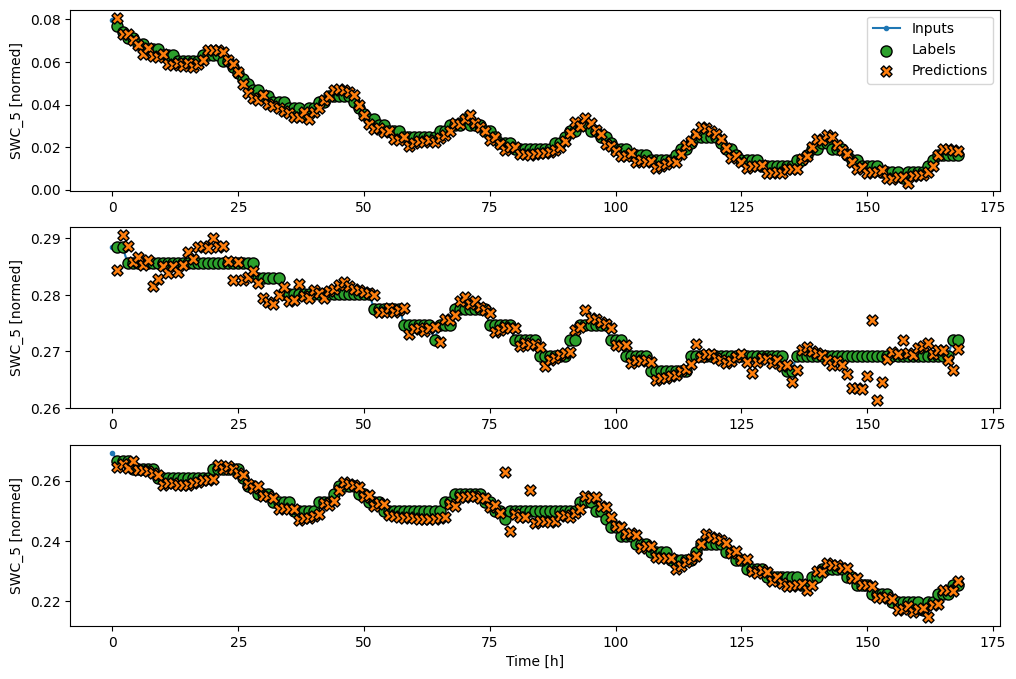

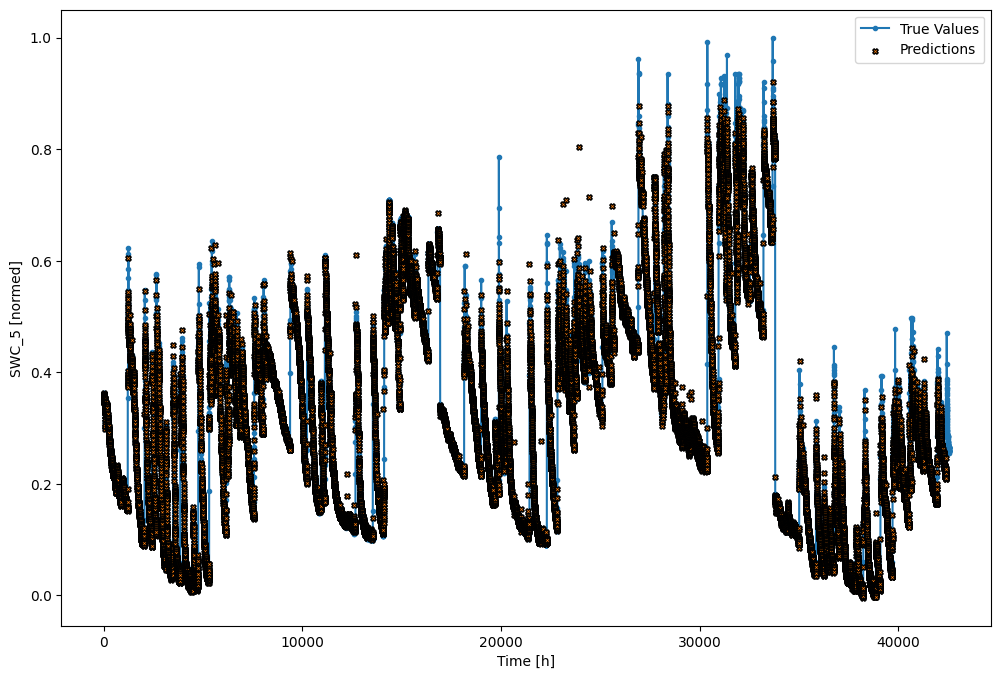

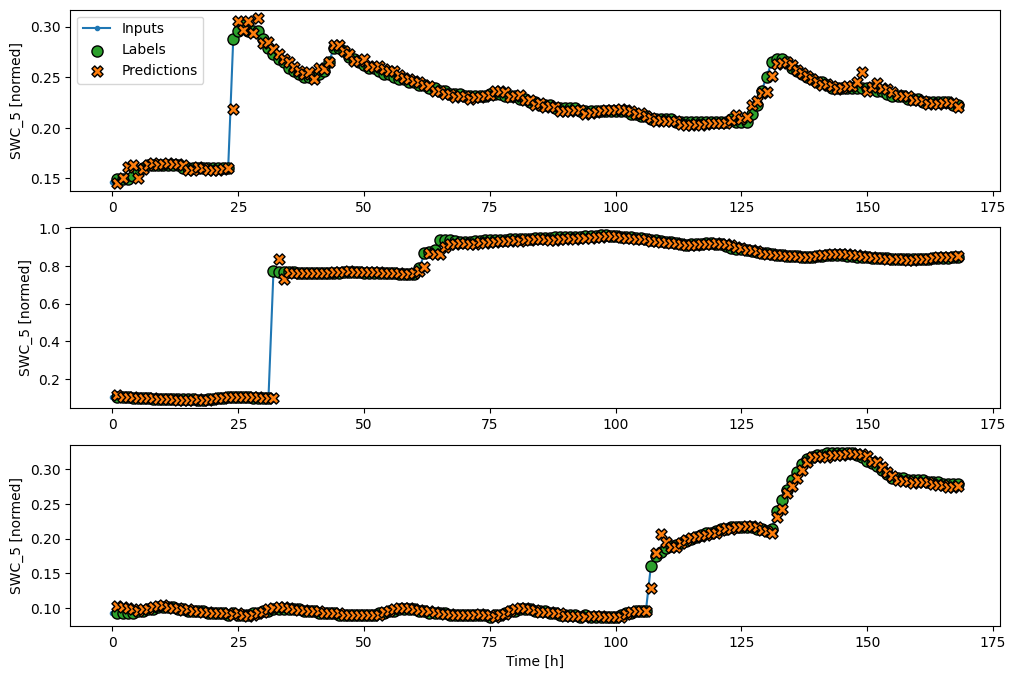

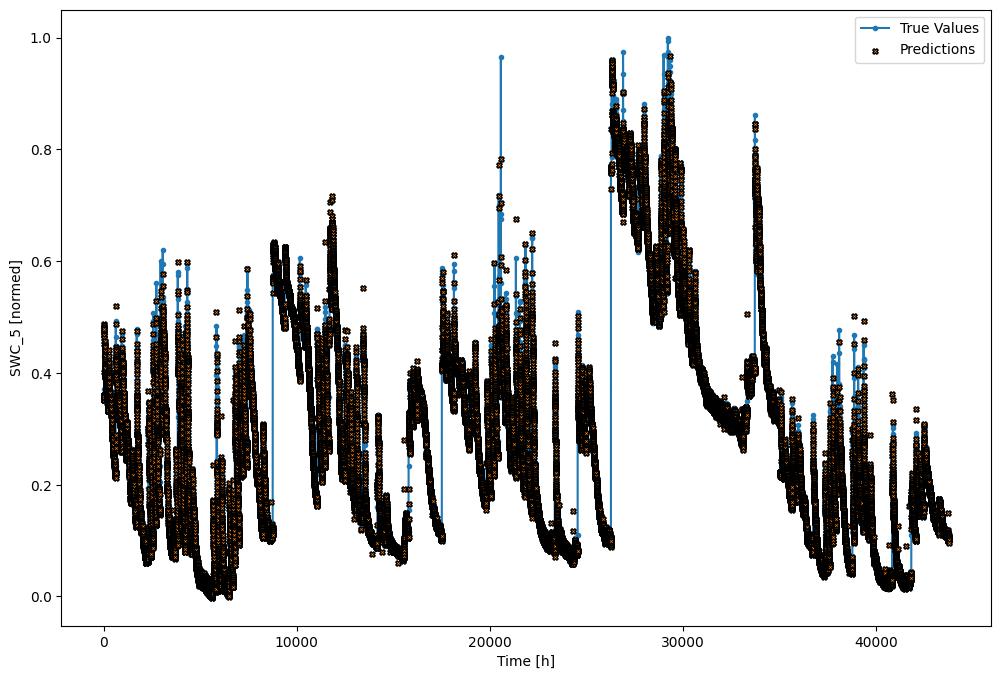

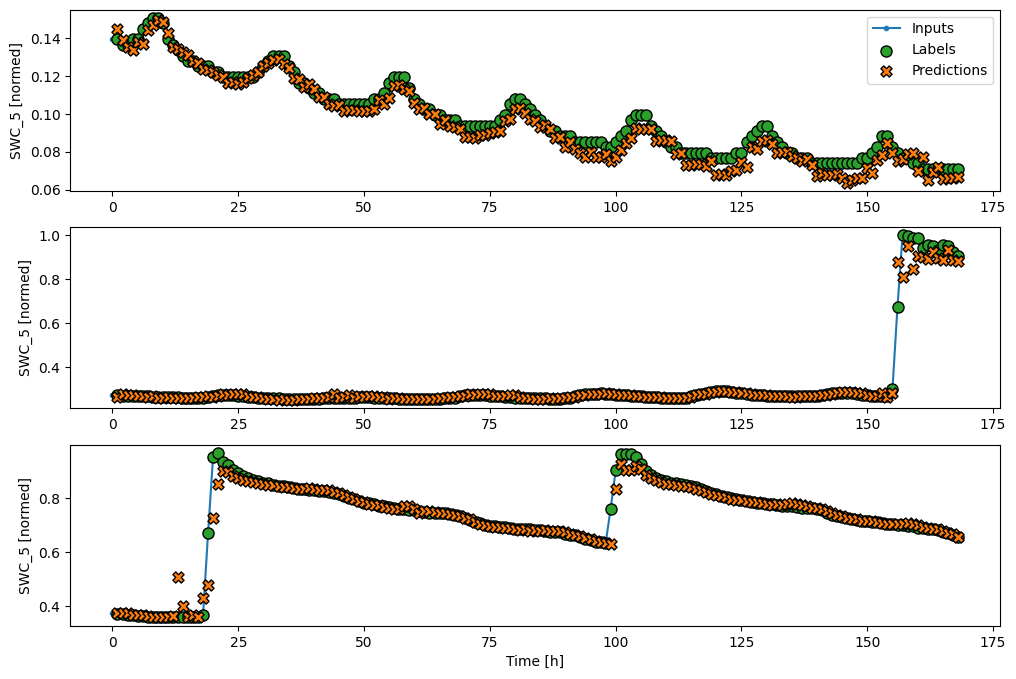

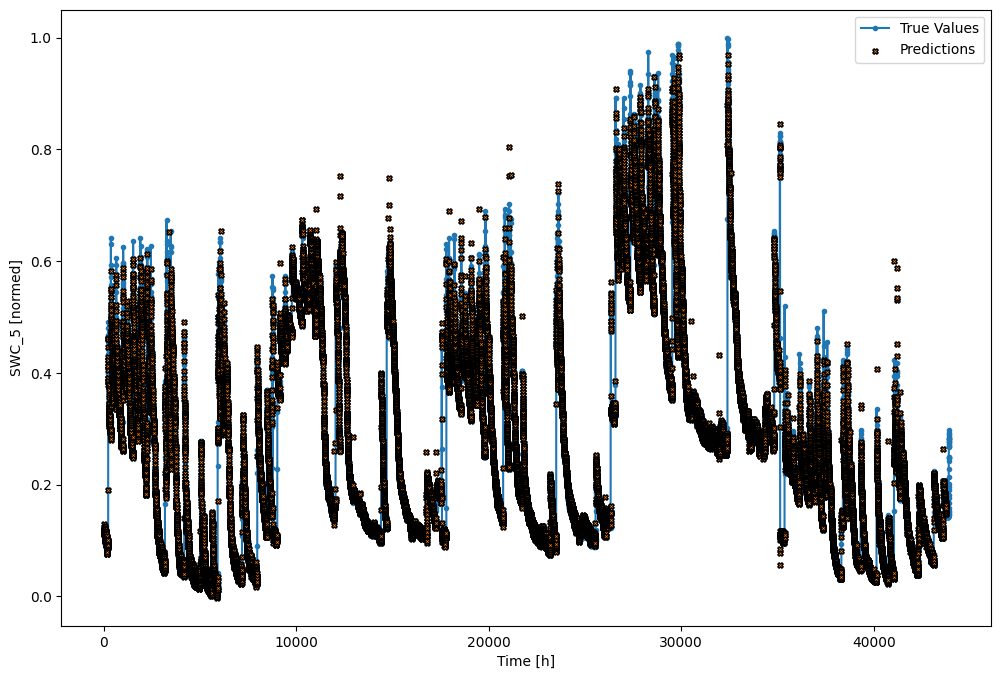

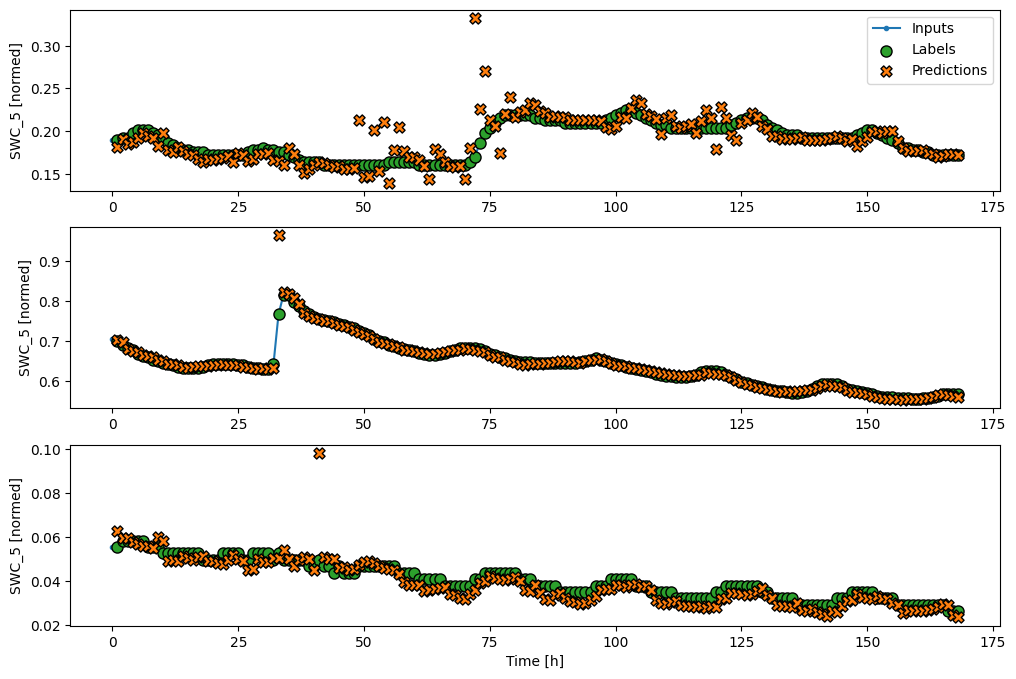

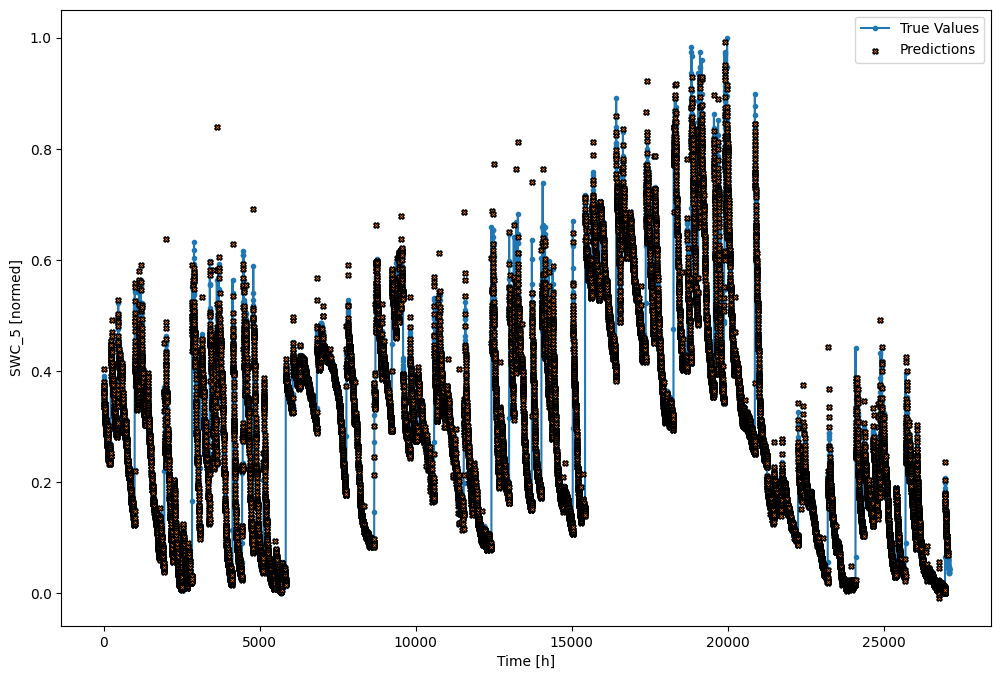

In [27]:
# Define the number of folds
n_folds = 7
days = 7

# Loop over the folds
for fold_idx in range(n_folds) :
    print(f'Fold {fold_idx + 1}')

    # modify the train, val, and test sets
    train_df, test_df = get_split(fold_idx)

    # normalize the datasets
    train_df, test_df = normalize(train_df, test_df)

    # generate the wide window to train on in this fold
    wide_window = WindowGenerator(
      input_width=24 * days, label_width=24 * days, shift=1,
      train_df=train_df, val_df=None, test_df=test_df,
      label_columns=['SWC_5'])
    
    # get the RNN LSTM model
    lstm_model = generate_lstm()
    
    # train and evaluate the RNN LSTM model
    history = compile_and_fit_noval(lstm_model, wide_window)
    
    # Evaluate the model on the test set
    performance['LSTM_fold-' + str(fold_idx + 1)] = lstm_model.evaluate(wide_window.test, verbose=0)

    # plot the results of the model (on random sets of test data)
    wide_window.plot(lstm_model)
    # plot the results of the model (on all of the test data)
    wide_window.plot_all(lstm_model)
    print()